# Dataset-level EDA
Goal: Understand the shape and health of the full dataset.

In [99]:
import os
from dotenv import load_dotenv
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import json
import pandas as pd
from impulse.collection.database import ImpulseDB

load_dotenv()

True

In [14]:
impulse_path = os.getenv('IMPULSE_PATH')
db_path = os.getenv('DB_PATH')

db = ImpulseDB(db_path)

Database initialized: /Users/david/dev/impulse/impulse.db


## Dataset-level statistics (DB only)
Examine information directly available in the db without loading any `.parquet` files. 

In [17]:
db_full_stats = db.get_full_stats()
raw_stats = db_full_stats['raw']
parsed_stats = db_full_stats['parsed']
db_full_stats 

{'raw': {'total_replays': 7312,
  'downloaded': 7312,
  'failed': 0,
  'pending': 0,
  'storage_mb': 11967.3,
  'storage_gb': 11.69},
 'parsed': {'total_entries': 7312,
  'parsed': 7282,
  'failed': 30,
  'total_frames': 72385745,
  'storage_mb': 21465.02,
  'storage_gb': 20.96}}

In [9]:
with sqlite3.connect(db_path) as conn:
    cursor = conn.execute("SELECT name, sql FROM sqlite_schema WHERE type='table' AND name NOT LIKE 'sqlite_%';")
    
    print("Database Schema:")
    for table_name, create_sql in cursor.fetchall():
        print(f"\nTable: {table_name}")
        print(f"CREATE statement:\n{create_sql}")

Database Schema:

Table: groups
CREATE statement:
CREATE TABLE groups (
                    group_id TEXT PRIMARY KEY,
                    name TEXT NOT NULL,
                    storage_path TEXT,
                    include_root_in_path BOOLEAN DEFAULT 1,
                    download_status TEXT DEFAULT 'pending',
                    replay_count INTEGER DEFAULT 0,
                    successful_count INTEGER DEFAULT 0,
                    failed_count INTEGER DEFAULT 0,
                    skipped_count INTEGER DEFAULT 0,
                    started_at TEXT,
                    completed_at TEXT,
                    CHECK (download_status IN ('pending', 'complete', 'partial', 'failed'))
                )

Table: raw_replays
CREATE statement:
CREATE TABLE raw_replays (
                    replay_id TEXT PRIMARY KEY,
                    group_id TEXT,
                    title TEXT,
                    date TEXT,
                    blue_team TEXT,
                    orange_team TEXT

### `groups` table

In [20]:
with sqlite3.connect(db_path) as conn:
    cursor = conn.cursor()
    cursor.execute("""
        SELECT name, storage_path, download_status, replay_count 
        FROM groups           
        """)
    print("Ballchasing group info:")
    for row in cursor.fetchall():
        print(f"Name: {row[0]} \n\tStorage Path: {row[1]} \n\tDownload Status: {row[2]} \n\tRaw replay Count: {row[3]}")

Ballchasing group info:
Name: RLCS 2024 
	Storage Path: replays/rlcs/2024 
	Download Status: complete 
	Raw replay Count: 7312


### `raw_replays` table

#### Validate `download_status`

In [34]:
with sqlite3.connect(db_path) as conn:
    cursor = conn.cursor()
    cursor.execute("""
        SELECT download_status, count(download_status)
        FROM raw_replays
        GROUP BY download_status
    """)
    rows = cursor.fetchall()
    for status, count in rows:
        print(f"Download Status: {status} \n\tCount: {count}")

Download Status: downloaded 
	Count: 7312


#### Validate `is_rlcs`

In [35]:
with sqlite3.connect(db_path) as conn:
    cursor = conn.cursor()
    cursor.execute("""
        SELECT is_rlcs,count(is_rlcs)
        FROM raw_replays
        GROUP BY is_rlcs
    """)
    rows = cursor.fetchall()
    for is_rlcs, count in rows:
        print(f"Is RLCS: {is_rlcs} \n\tCount: {count}")

Is RLCS: 1 
	Count: 7312


#### Validate `team_size`

In [36]:
with sqlite3.connect(db_path) as conn:
    cursor = conn.cursor()
    
    cursor.execute("""
        SELECT team_size, count(team_size)
        FROM raw_replays
        GROUP BY team_size
    """)
    rows = cursor.fetchall()
    for team_size, count in rows:
        print(f"Team Size: {team_size} \n\tCount: {count}")

Team Size: 3 
	Count: 5831
Team Size: 4 
	Count: 1481


### Raw file sizes

count    7312.00
mean        1.64
std         0.32
min         0.03
25%         1.49
50%         1.56
75%         1.68
max         5.15
dtype: float64


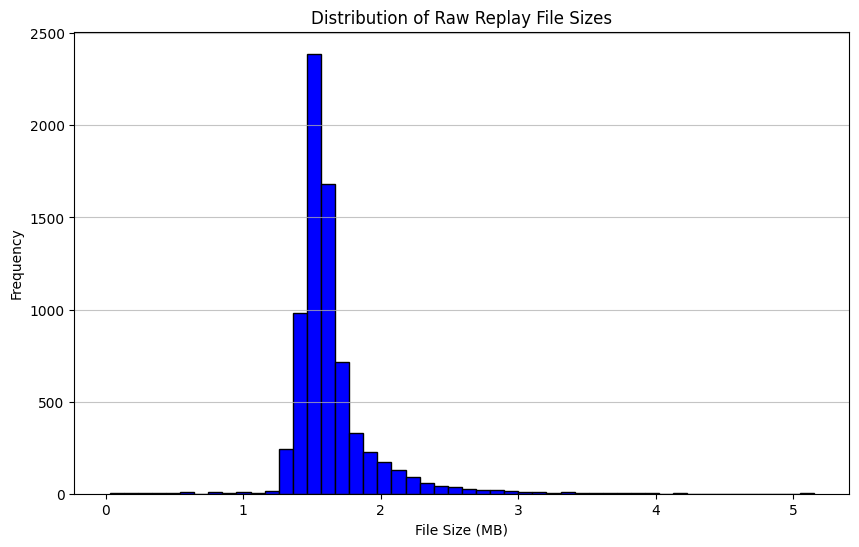

In [49]:
with sqlite3.connect(db_path) as conn:
    cursor = conn.cursor()
    cursor.execute("""
        SELECT file_size_bytes
        FROM raw_replays           
        """)
    file_sizes = [row[0] for row in cursor.fetchall()]

file_sizes_mb = [size / (1024 * 1024) for size in file_sizes]

print(pd.Series(file_sizes_mb).describe().round(2))

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(file_sizes_mb, bins=50, color='blue', edgecolor='black')
ax.set_title('Distribution of Raw Replay File Sizes')
ax.set_xlabel('File Size (MB)')
ax.set_ylabel('Frequency')
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.grid(axis='y', alpha=0.75)
plt.show()


#### Replay duration (seconds)

count    7312.000000
mean      365.612008
std        62.818730
min         2.000000
25%       337.000000
50%       352.000000
75%       373.000000
max      1133.000000
dtype: float64


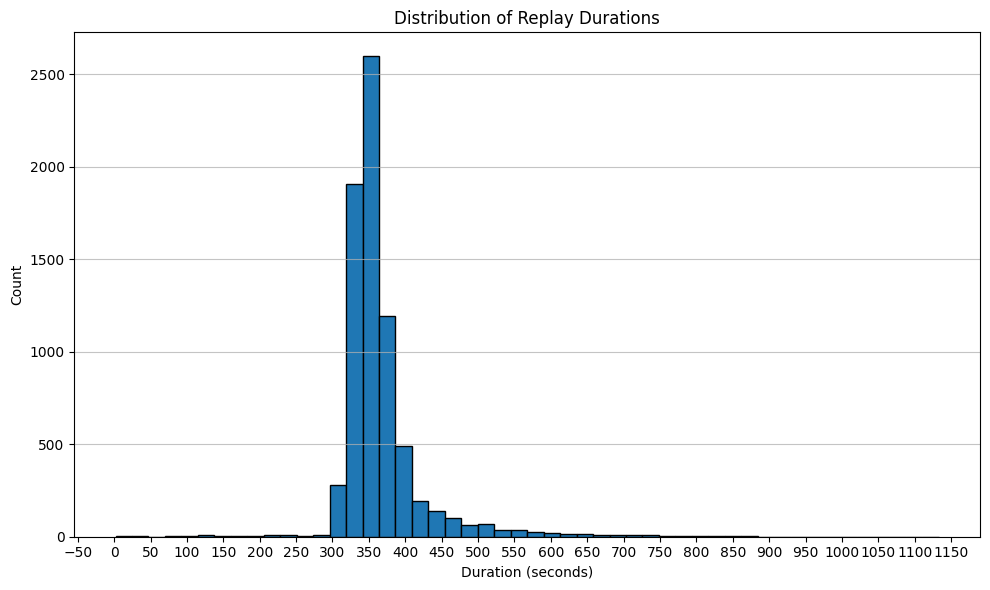

In [60]:
with sqlite3.connect(db_path) as conn:
    cursor = conn.cursor()
    cursor.execute("""
        SELECT duration 
        FROM raw_replays
        """)
    durations = [row[0] for row in cursor.fetchall()]

print(pd.Series(durations).describe())

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(durations, bins=50, edgecolor='black')
ax.set_title('Distribution of Replay Durations')
ax.set_xlabel('Duration (seconds)')
ax.set_ylabel('Count')
ax.xaxis.set_major_locator(ticker.MultipleLocator(50))
ax.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

#### Games with overtime

[(0, 5745), (1, 1567)]
[0, 1] [5745, 1567]


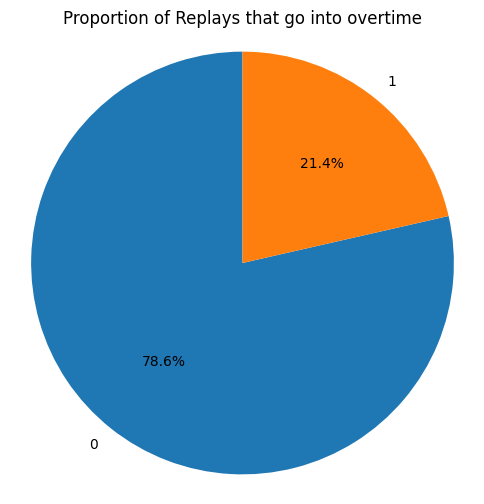

In [56]:
with sqlite3.connect(db_path) as conn:
    cursor = conn.cursor()
    cursor.execute("""
        SELECT overtime, count(overtime)
        FROM raw_replays
        GROUP BY overtime           
    """)
    rows = cursor.fetchall()
    print(rows)
    labels = [row[0] for row in rows]
    counts = [row[1] for row in rows]

print(labels, counts)
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90)
ax.set_title('Proportion of Replays that go into overtime')
plt.axis('equal')
plt.show()

#### Overtime duration

Nan value count: 67/1567

count    1500.000000
mean       91.989333
std       100.201837
min         1.000000
25%        27.000000
50%        60.500000
75%       123.000000
max      1197.000000
dtype: float64


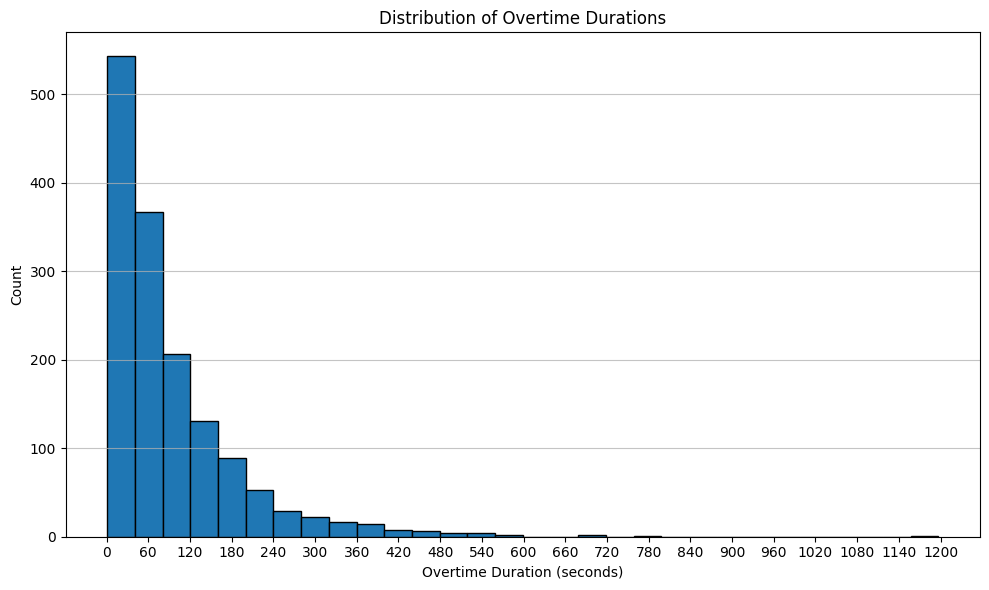

In [67]:
with sqlite3.connect(db_path) as conn:
    cursor = conn.cursor()
    cursor.execute("""
        SELECT overtime_seconds
        FROM raw_replays
        WHERE overtime = 1           
    """)
    overtime_seconds = pd.Series([row[0] for row in cursor.fetchall()])

print(f"Nan value count: {overtime_seconds.isna().sum()}/{len(overtime_seconds)}\n")
print(overtime_seconds.describe())

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(overtime_seconds, bins=30, edgecolor='black')
ax.set_title('Distribution of Overtime Durations')
ax.set_xlabel('Overtime Duration (seconds)')
ax.set_ylabel('Count')
ax.xaxis.set_major_locator(ticker.MultipleLocator(60))
ax.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

#### Map frequency

In [68]:
with sqlite3.connect(db_path) as conn:
    cursor = conn.cursor()
    cursor.execute("""
        SELECT map_name, count(map_name)
        FROM raw_replays
        GROUP BY map_name
    """)
    rows = cursor.fetchall()
    for map_name, count in rows:
        print(f"Map Name: {map_name} \n\tCount: {count}")

Map Name: AquaDome (Salty Shallows) 
	Count: 131
Map Name: Beckwith Park (Stormy) 
	Count: 1
Map Name: Champions Field 
	Count: 420
Map Name: DFH Stadium 
	Count: 1811
Map Name: DFH Stadium (Day) 
	Count: 30
Map Name: Deadeye Canyon (Oasis) 
	Count: 21
Map Name: Forbidden Temple 
	Count: 1193
Map Name: Forbidden Temple (Day) 
	Count: 1
Map Name: Mannfield 
	Count: 1
Map Name: Mannfield (Dusk) 
	Count: 163
Map Name: Mannfield (Night) 
	Count: 2026
Map Name: Neo Tokyo (Standard) 
	Count: 91
Map Name: Urban Central (Night) 
	Count: 1
Map Name: Utopia Coliseum 
	Count: 22
Map Name: Utopia Coliseum (Dusk) 
	Count: 1396
Map Name: Utopia Coliseum (Gilded) 
	Count: 1
Map Name: Wasteland (Standard, Night) 
	Count: 3


#### Most frequently appearing teams

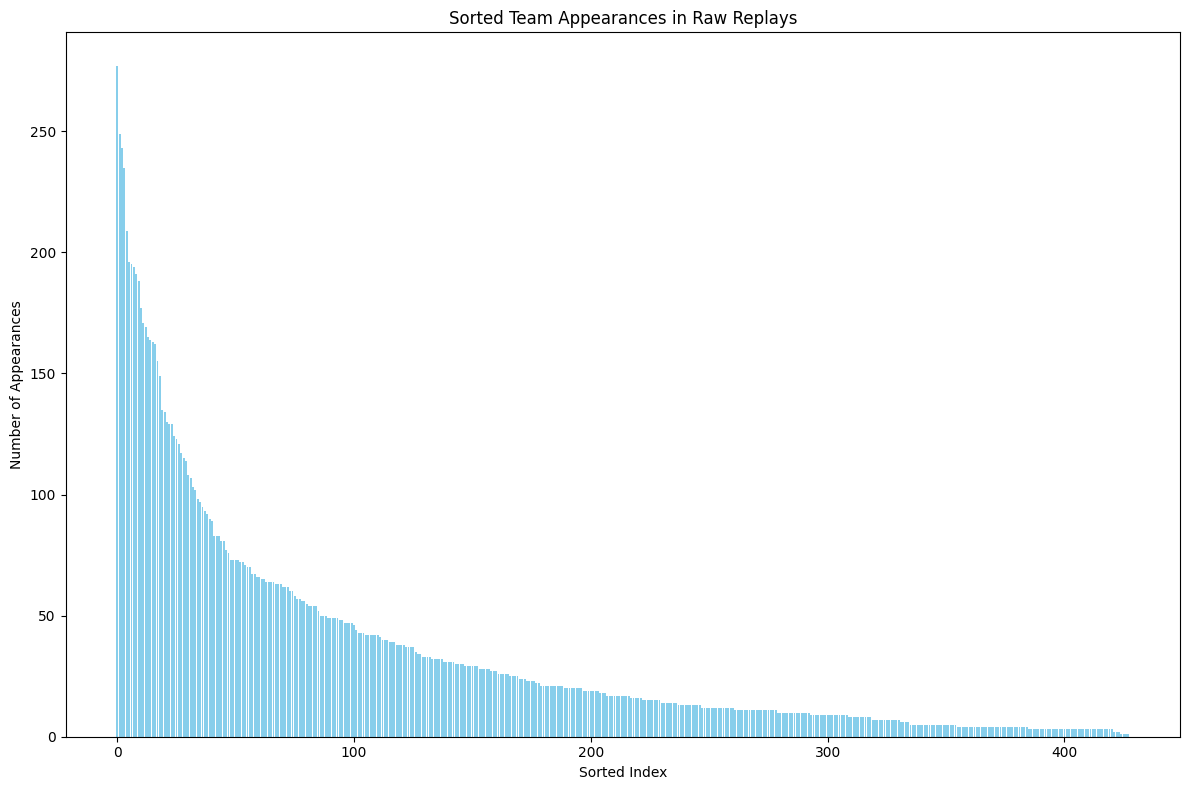

In [81]:
with sqlite3.connect(db_path) as conn:
    cursor = conn.cursor()
    cursor.execute("""
        SELECT team, COUNT(*) as appearances
        FROM (
            SELECT orange_team AS team FROM raw_replays
            UNION ALL
            SELECT blue_team AS team FROM raw_replays
        )
        GROUP BY team
        ORDER BY appearances DESC               
    """)
    rows = cursor.fetchall()

teams = [row[0] for row in rows]
counts = [row[1] for row in rows]
team_appearances = pd.DataFrame({'team': teams, 'appearances': counts})

fig, ax = plt.subplots(figsize=(12, 8))
ax.bar(team_appearances.index, team_appearances['appearances'], color='skyblue')
ax.set_title('Sorted Team Appearances in Raw Replays')
ax.set_ylabel('Number of Appearances')
ax.set_xlabel('Sorted Index')
plt.tight_layout()
plt.show()    

/var/folders/sz/kx_yftld6rs9z42kwpsm47y40000gn/T/ipykernel_56813/986557615.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(team_appearances.iloc[:20]['team'], rotation=90)


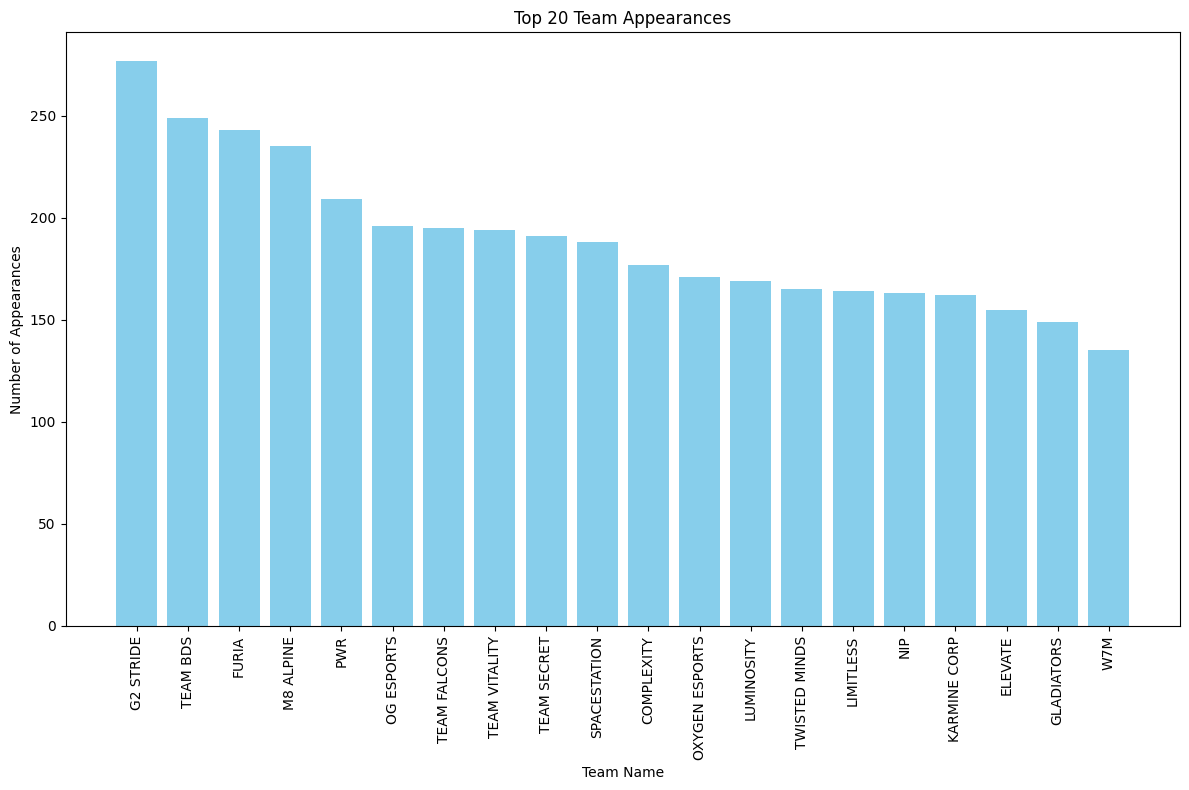

In [83]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.bar(team_appearances.iloc[:20]['team'], team_appearances.iloc[:20]['appearances'], color='skyblue')
ax.set_title('Top 20 Team Appearances')
ax.set_ylabel('Number of Appearances')
ax.set_xlabel('Team Name')
ax.set_xticklabels(team_appearances.iloc[:20]['team'], rotation=90)
plt.tight_layout()
plt.show()

#### Goal distribution

In [84]:
# blue_goals and orange_goals columns are both empty in the raw_replays table, needs lookin at 

### `parsed_replays` table

In [87]:
parse_fail_rate = parsed_stats['failed'] / (parsed_stats['parsed'] + parsed_stats['failed'])
print(f"Parsing Failure Rate: {parse_fail_rate:.2%}")
print(f"Parsing failure count: {parsed_stats['failed']} out of {parsed_stats['parsed'] + parsed_stats['failed']} total replays")
print(f"Successful parse count: {parsed_stats['parsed']}")

Parsing Failure Rate: 0.41%
Parsing failure count: 30 out of 7312 total replays
Successful parse count: 7282


#### Validate `output_format`

In [85]:
with sqlite3.connect(db_path) as conn:
    cursor = conn.cursor()
    cursor.execute("""
        SELECT output_format, count(output_format)
        FROM parsed_replays
        GROUP BY output_format               
    """)
    rows = cursor.fetchall()

for format, count in rows:
    print(f"Output Format: {format} \n\tCount: {count}")

Output Format: None 
	Count: 0
Output Format: parquet 
	Count: 7282


#### Validate `fps`

In [90]:
with sqlite3.connect(db_path) as conn:
    cursor = conn.cursor()
    cursor.execute("""
        SELECT fps, count(fps)
        FROM parsed_replays  
        GROUP BY fps            
    """)
    rows = cursor.fetchall()
for fps, count in rows:
    print(f"FPS: {fps} \n\tCount: {count}")

FPS: None 
	Count: 0
FPS: 30.0 
	Count: 7282


#### Validate `parse_status`

In [91]:
with sqlite3.connect(db_path) as conn:
    cursor = conn.cursor()
    cursor.execute("""
        SELECT parse_status, count(parse_status)
        FROM parsed_replays
        GROUP BY parse_status               
    """)
    rows = cursor.fetchall()
for status, count in rows:
    print(f"Parse Status: {status} \n\tCount: {count}")

Parse Status: failed 
	Count: 30
Parse Status: parsed 
	Count: 7282


#### Validate `is_rlcs`

In [92]:
with sqlite3.connect(db_path) as conn:
    cursor = conn.cursor()
    cursor.execute("""
        SELECT is_rlcs, count(is_rlcs)
        FROM parsed_replays
        GROUP BY is_rlcs               
    """)
    rows = cursor.fetchall()
for is_rlcs, count in rows:
    print(f"Is RLCS: {is_rlcs} \n\tCount: {count}")

Is RLCS: 0 
	Count: 30
Is RLCS: 1 
	Count: 7282


#### Parsed file size distribution

count    7282.000000
mean        2.947683
std         0.557697
min         0.100840
25%         2.743501
50%         2.803894
75%         2.936073
max         9.962317
dtype: float64


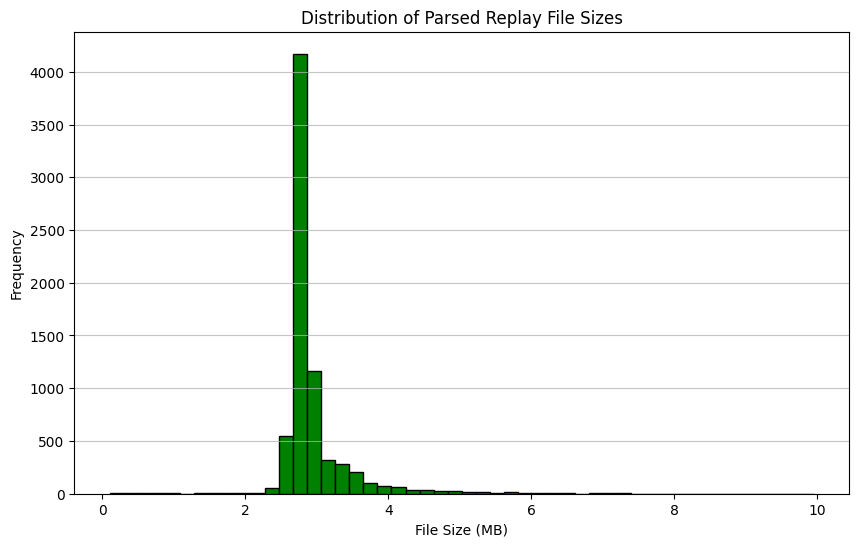

In [94]:
with sqlite3.connect(db_path) as conn:
    cursor = conn.cursor()
    cursor.execute("""
        SELECT file_size_bytes
        FROM parsed_replays               
    """)
    rows = cursor.fetchall()
file_sizes_parsed_mb = pd.Series([row[0] / (1024 * 1024) for row in rows if row[0] is not None])
print(file_sizes_parsed_mb.describe())

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(file_sizes_parsed_mb, bins=50, color='green', edgecolor='black')
ax.set_title('Distribution of Parsed Replay File Sizes')
ax.set_xlabel('File Size (MB)')
ax.set_ylabel('Frequency')
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.grid(axis='y', alpha=0.75)
plt.show()


#### Distribution of frame counts

count     7282.000000
mean      9940.365971
std       1786.866800
min        117.000000
25%       9314.250000
50%       9456.000000
75%       9724.000000
max      33234.000000
dtype: float64


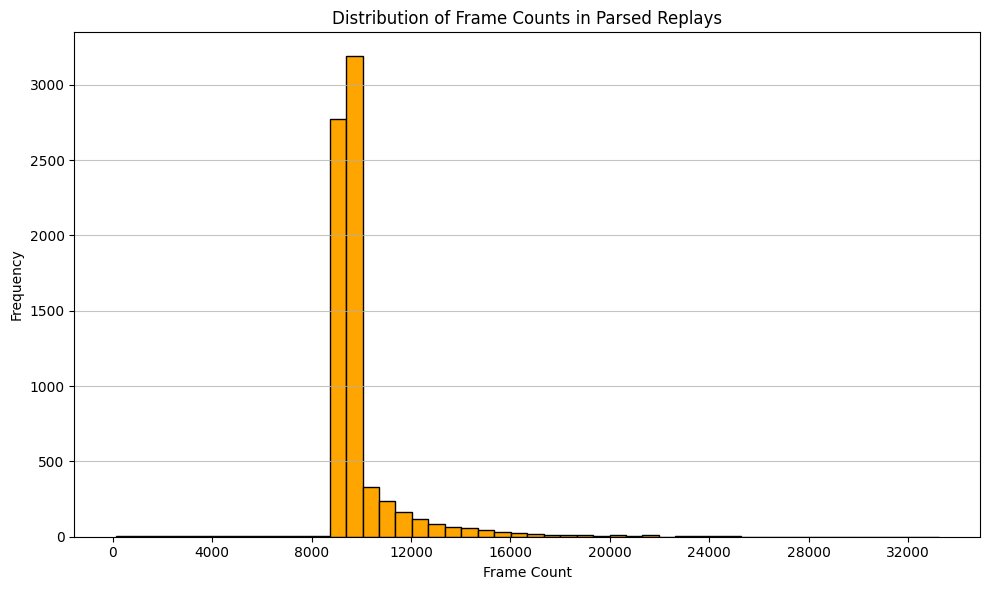

In [96]:
with sqlite3.connect(db_path) as conn:
    cursor = conn.cursor()
    cursor.execute("""
        SELECT frame_count
        FROM parsed_replays               
    """)
    rows = cursor.fetchall()
frame_counts = pd.Series([row[0] for row in rows if row[0] is not None])
print(frame_counts.describe())

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(frame_counts, bins=50, color='orange', edgecolor='black')
ax.set_title('Distribution of Frame Counts in Parsed Replays')
ax.set_xlabel('Frame Count')
ax.set_ylabel('Frequency')
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

#### Example `metadata`

In [111]:
with sqlite3.connect(db_path) as conn:
    cursor = conn.cursor()
    cursor.execute("""
        SELECT metadata
        FROM parsed_replays
        LIMIT 1               
    """)
    rows = cursor.fetchall()

metadata_sample = rows[0][0] if rows else None
print(type(metadata_sample))
print(json.dumps(metadata_sample, indent=4))

<class 'str'>
"{\"replay_id\": \"0328fc07-13fb-4cb6-9a86-7d608196ddbd\", \"source_file\": \"/tmp/tmpu7m814pb/0328fc07-13fb-4cb6-9a86-7d608196ddbd.replay\", \"ballchasing_id\": \"E6080ABC4A13F12C2BBF4A8837E51D04\", \"replay_name\": \"WORLDS P-I BDS vs G2 G6 2024-09-15.18.21\", \"date\": \"2024-09-15 18-21-19\", \"map\": \"NeoTokyo_Standard_P\", \"match_type\": \"Lan\", \"team_size\": 3, \"num_frames\": 10565, \"fps\": 30.0, \"duration_seconds\": 312.73333333333335, \"team_0_score\": 3, \"team_1_score\": 2, \"goals\": [{\"PlayerName\": \"dralii\", \"PlayerTeam\": 0, \"frame\": 3475}, {\"PlayerName\": \"BeastMode\", \"PlayerTeam\": 1, \"frame\": 3817}, {\"PlayerName\": \"dralii\", \"PlayerTeam\": 0, \"frame\": 7046}, {\"PlayerName\": \"Daniel\", \"PlayerTeam\": 1, \"frame\": 7863}, {\"PlayerName\": \"dralii\", \"PlayerTeam\": 0, \"frame\": 9996}], \"highlights\": [{\"BallName\": \"Ball_TA_108\", \"CarName\": \"Car_TA_714\", \"GoalActorName\": \"None\", \"frame\": 375}, {\"BallName\": \"Ba